In [49]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings("ignore")
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.model_selection import train_test_split


In [2]:
df = pd.read_csv('dirty_cafe_sales.csv')

In [3]:
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [4]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


(10000, 8)

In [5]:
df.tail()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02
9999,TXN_6170729,Sandwich,3,4.0,12.0,Cash,In-store,2023-11-07


In [6]:
#summary stats
df.describe(include='all')

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_1961373,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


In [7]:
#missing values 
df.isnull().sum()

Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

In [8]:
#identifying garabage values
for i in df.select_dtypes(include="object").columns:
           print(df[i].value_counts())
           print("***"*10)

Transaction ID
TXN_1961373    1
TXN_4831525    1
TXN_1228927    1
TXN_6486912    1
TXN_3447069    1
              ..
TXN_5680238    1
TXN_7766134    1
TXN_2617257    1
TXN_8993132    1
TXN_6170729    1
Name: count, Length: 10000, dtype: int64
******************************
Item
Juice       1171
Coffee      1165
Salad       1148
Cake        1139
Sandwich    1131
Smoothie    1096
Cookie      1092
Tea         1089
UNKNOWN      344
ERROR        292
Name: count, dtype: int64
******************************
Quantity
5          2013
2          1974
4          1863
3          1849
1          1822
UNKNOWN     171
ERROR       170
Name: count, dtype: int64
******************************
Price Per Unit
3.0        2429
4.0        2331
2.0        1227
5.0        1204
1.0        1143
1.5        1133
ERROR       190
UNKNOWN     164
Name: count, dtype: int64
******************************
Total Spent
6.0        979
12.0       939
3.0        930
4.0        923
20.0       746
15.0       734
8.0        677

In [9]:
# duplicates check 
df.duplicated().sum()

0

In [10]:
df.dtypes

Transaction ID      object
Item                object
Quantity            object
Price Per Unit      object
Total Spent         object
Payment Method      object
Location            object
Transaction Date    object
dtype: object

In [11]:
#cleaning the data base
# fixing the dtype
df['Quantity'].dtype
df['Quantity'].unique()
for i in (['Price Per Unit','Total Spent']):
    df[i] = pd.to_numeric(df[i],errors='coerce')
    df = df.dropna(subset=[i])
    
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
df['Quantity'] = df['Quantity'].astype('Int64')




In [12]:
#fixing date dtype
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors='coerce')

In [13]:
df.dtypes

Transaction ID              object
Item                        object
Quantity                     Int64
Price Per Unit             float64
Total Spent                float64
Payment Method              object
Location                    object
Transaction Date    datetime64[ns]
dtype: object

In [14]:
#handling missing values were applicable 
#median(numeric)depending on the skewenss  mode (categorial)
df['Item'].fillna(df['Item'].mode()[0], inplace=True)
df['Payment Method'].fillna(df['Payment Method'].mode()[0], inplace=True)



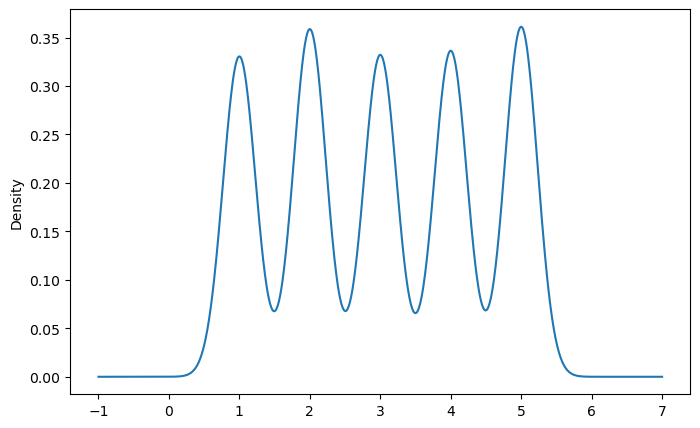

In [15]:
# checking the distribution of the numeric missing data
plt.figure(figsize=(8,5))
df['Quantity'].plot(kind = 'kde')
plt.show()

In [16]:
#handling missing nemeric value 
df['Quantity'].fillna(df['Quantity'].median(), inplace=True)

In [17]:
# drop empty dates
df = df.dropna(subset=['Transaction Date'])

In [18]:
df['Location'].fillna(df['Location'].mode()[0], inplace=True)

In [60]:
df.isnull().sum()

Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64

In [20]:
#handling garberg values 
garbage = ['ERROR', 'UNKNOWN']

for col in ['Item', 'Payment Method', 'Location']:
    df[col] = df[col].replace(garbage, np.nan)

In [21]:
for col in ['Item', 'Payment Method', 'Location']:
    df[col] = df[col].fillna(df[col].mode()[0])

In [22]:
#dropping unnccessary columns
df.drop(['Transaction ID'], axis = 1 , inplace = True)

In [23]:
df.head()

,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
3,Salad,2,5.0,10.0,Digital Wallet,Takeaway,2023-04-27
4,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,Smoothie,5,4.0,20.0,Credit Card,Takeaway,2023-03-31


In [24]:
#Exploratory Data Analysis (EDA)
df.describe()

,Quantity,Price Per Unit,Total Spent,Transaction Date
count,8577.0,8577.000000,8577.000000,8577
mean,3.017605,2.947184,8.900956,2023-07-01 22:50:49.737670400
min,1.0,1.000000,1.000000,2023-01-01 00:00:00
25%,2.0,2.000000,4.000000,2023-04-02 00:00:00
50%,3.0,3.000000,8.000000,2023-07-02 00:00:00
75%,4.0,4.000000,12.000000,2023-10-01 00:00:00
max,5.0,5.000000,25.000000,2023-12-31 00:00:00
std,1.382963,1.277887,5.999904,NaN


In [25]:
df.describe(include = 'object')

,Item,Payment Method,Location
count,8577,8577,8577
unique,8,3,2
top,Coffee,Digital Wallet,Takeaway
freq,1851,4688,5985


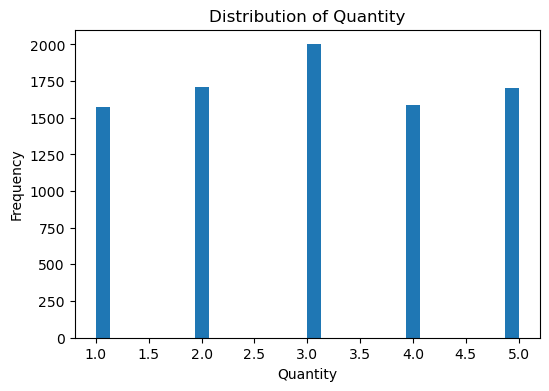

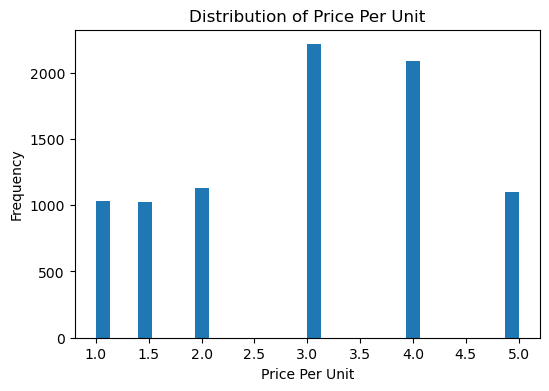

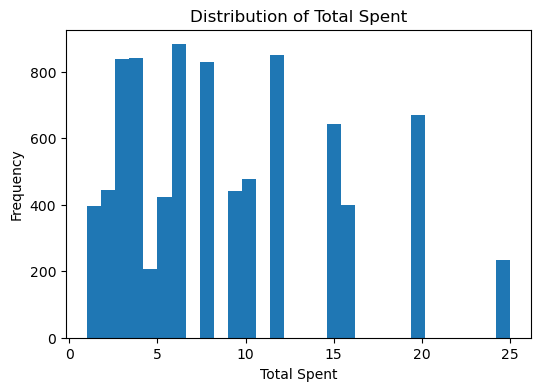

In [26]:
#histogram distribution
num_cols = ['Quantity', 'Price Per Unit', 'Total Spent']

for col in num_cols:
    plt.figure(figsize=(6,4))
    plt.hist(df[col].astype(float).dropna(), bins=30) 
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

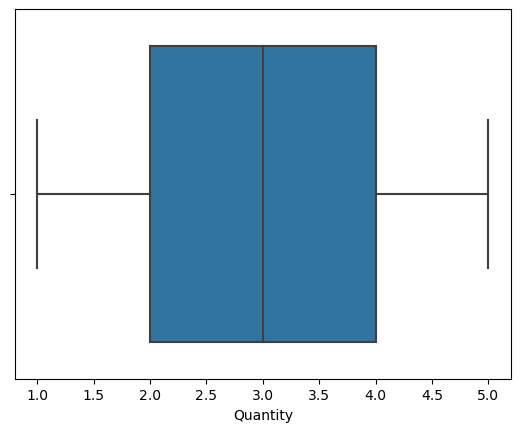

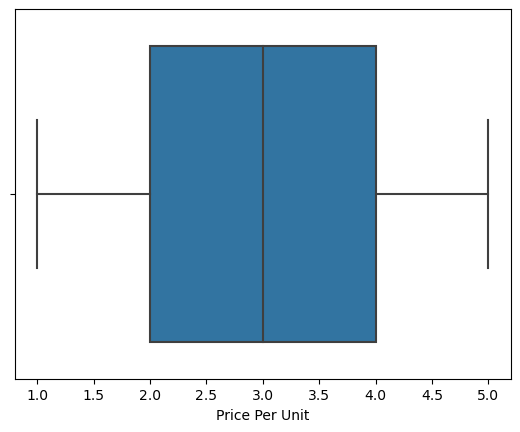

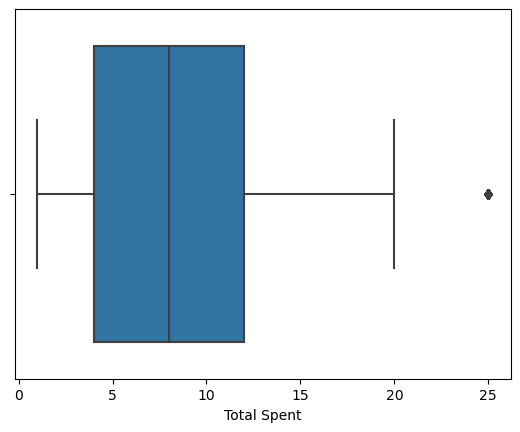

In [27]:
#boxplot to identify outliers
for i in df.select_dtypes(include="number").columns:
    sns.boxplot(data=df,x=i)
    plt.show()

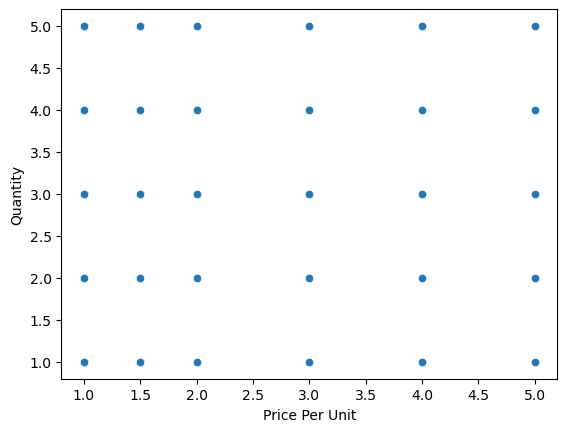

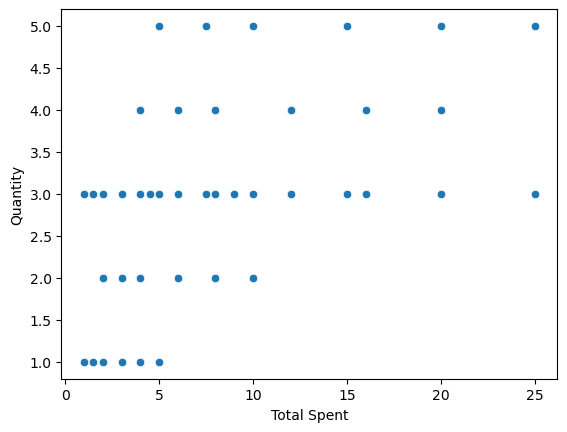

In [29]:
#scatter plot to understand the relationship
for i in['Price Per Unit', 'Total Spent']:
    sns.scatterplot(data = df , x= i , y='Quantity')
    plt.show()


In [30]:
#Item
df['Item'].value_counts()

Item
Coffee      1851
Juice       1014
Salad        985
Cake         984
Sandwich     969
Cookie       926
Smoothie     925
Tea          923
Name: count, dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

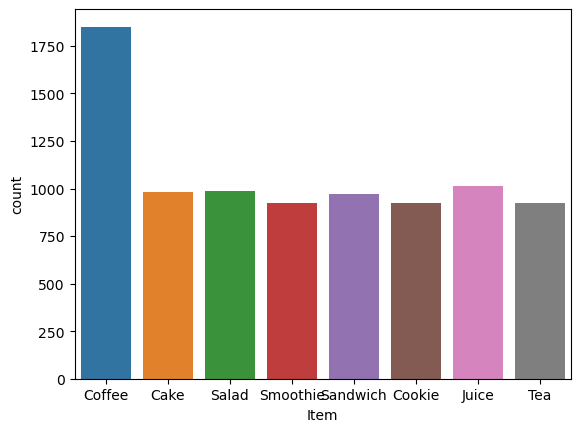

In [31]:
sns.countplot(data=df, x='Item')
plt.show

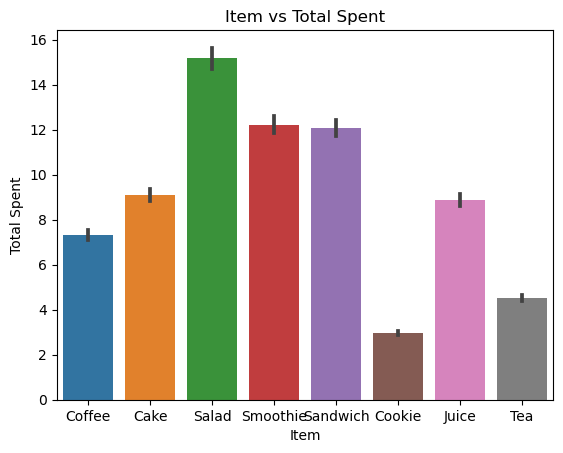

In [36]:
sns.barplot(data=df, x='Item', y='Total Spent')
plt.title('Item vs Total Spent')
plt.show()



In [37]:
#payment method
df['Payment Method'].value_counts()

Payment Method
Digital Wallet    4688
Credit Card       1954
Cash              1935
Name: count, dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

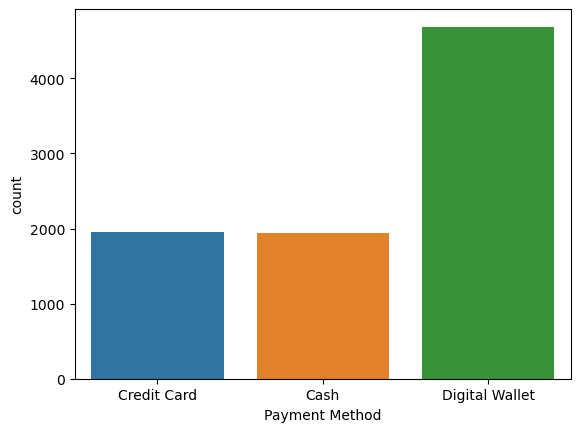

In [38]:
sns.countplot(data=df, x='Payment Method')
plt.show

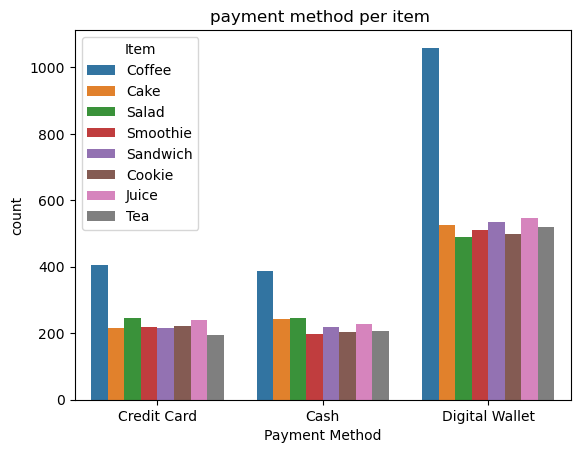

In [43]:
sns.countplot(data=df, x='Payment Method', hue='Item')
plt.title('payment method per item ')
plt.show()


In [53]:
df['Location'].value_counts()

Location
Takeaway    5985
In-store    2592
Name: count, dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

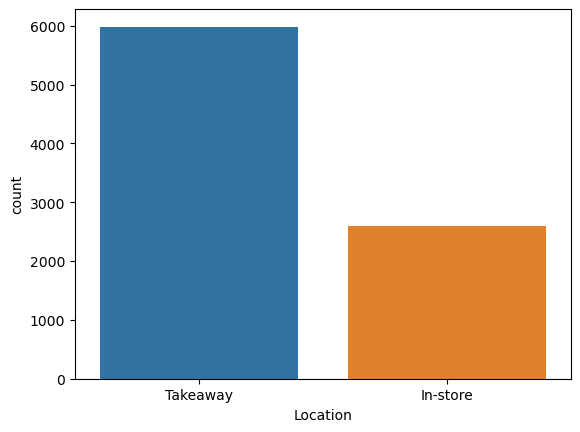

In [54]:
sns.countplot(data=df, x='Location')
plt.show

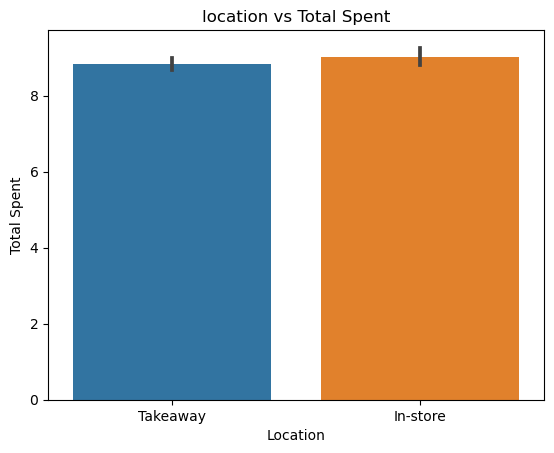

In [56]:
sns.barplot(data=df, x='Location', y='Total Spent')
plt.title('location vs Total Spent')
plt.show()

In [45]:
Q1 = df['Total Spent'].quantile(0.25)
Q3 = df['Total Spent'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['Total Spent'] < Q1 - 1.5*IQR) | (df['Total Spent'] > Q3 + 1.5*IQR)]
outliers.head()

,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
10,Salad,5,5.0,25.0,Cash,Takeaway,2023-11-07
51,Salad,5,5.0,25.0,Digital Wallet,Takeaway,2023-01-08
52,Coffee,5,5.0,25.0,Digital Wallet,Takeaway,2023-03-15
96,Salad,5,5.0,25.0,Cash,In-store,2023-06-10
100,Coffee,5,5.0,25.0,Cash,Takeaway,2023-10-30


In [48]:
df_no_outliers = df[~((df['Total Spent'] < Q1 - 1.5*IQR) | (df['Total Spent'] > Q3 + 1.5*IQR))]


In [58]:
#Data Transformation
#Encoding Categorical Variables
df_encoded = pd.get_dummies(data=df_no_outliers, columns=["Item","Payment Method","Location"],drop_first=True)

In [59]:
df_encoded

,Quantity,Price Per Unit,Total Spent,Transaction Date,Item_Coffee,Item_Cookie,Item_Juice,Item_Salad,Item_Sandwich,Item_Smoothie,Item_Tea,Payment Method_Credit Card,Payment Method_Digital Wallet,Location_Takeaway
0,2,2.0,4.0,2023-09-08,True,False,False,False,False,False,False,True,False,True
1,4,3.0,12.0,2023-05-16,False,False,False,False,False,False,False,False,False,False
3,2,5.0,10.0,2023-04-27,False,False,False,True,False,False,False,False,True,True
4,2,2.0,4.0,2023-06-11,True,False,False,False,False,False,False,False,True,False
5,5,4.0,20.0,2023-03-31,False,False,False,False,False,True,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9992,4,4.0,16.0,2023-07-05,False,False,False,False,False,True,False,False,True,False
9994,4,4.0,16.0,2023-01-08,True,False,False,False,False,False,False,False,True,True
9995,2,2.0,4.0,2023-08-30,True,False,False,False,False,False,False,False,True,True
9997,4,2.0,8.0,2023-03-02,True,False,False,False,False,False,False,False,True,True


In [62]:
#Feature Scaling
#depending on which model that involve gradient or distance like neural networks knns pca
scaler = StandardScaler()
df_encoded[['Quantity','Total Spent','Price Per Unit']] = scaler.fit_transform(df_encoded[['Quantity','Total Spent','Price Per Unit']])

In [ ]:
#Feature Engineering
#Creating New Features


In [63]:
# Ensure 'Transaction Date' is in datetime format
df_encoded['Transaction Date'] = pd.to_datetime(df_encoded['Transaction Date'], errors='coerce')

In [64]:
# Create new features
df_encoded['Day'] = df_encoded['Transaction Date'].dt.day
df_encoded['Month'] = df_encoded['Transaction Date'].dt.month
df_encoded['Year'] = df_encoded['Transaction Date'].dt.year

In [65]:
df_encoded[['Transaction Date','Day','Month','Year']].head()

,Transaction Date,Day,Month,Year
0,2023-09-08,8,9,2023
1,2023-05-16,16,5,2023
3,2023-04-27,27,4,2023
4,2023-06-11,11,6,2023
5,2023-03-31,31,3,2023


In [66]:
df_encoded = df_encoded.drop('Transaction Date', axis=1)

In [67]:
df_encoded.head()


,Quantity,Price Per Unit,Total Spent,Item_Coffee,Item_Cookie,Item_Juice,Item_Salad,Item_Sandwich,Item_Smoothie,Item_Tea,Payment Method_Credit Card,Payment Method_Digital Wallet,Location_Takeaway,Day,Month,Year
0,-0.707742,-0.712921,-0.818774,True,False,False,False,False,False,False,True,False,True,8,9,2023
1,0.759262,0.088467,0.653372,False,False,False,False,False,False,False,False,False,False,16,5,2023
3,-0.707742,1.691242,0.285335,False,False,False,True,False,False,False,False,True,True,27,4,2023
4,-0.707742,-0.712921,-0.818774,True,False,False,False,False,False,False,False,True,False,11,6,2023
5,1.492764,0.889854,2.125518,False,False,False,False,False,True,False,True,False,True,31,3,2023


In [76]:
#Binning Continuous Variables
df_encoded['PricePerUnit_group'] = pd.cut(
    df_encoded['Price Per Unit'], 
    bins=[-1, 1, 3, 4, 5], 
    labels=['Cheap', 'Affordable', 'Expensive', 'Very Expensive']
)

In [77]:
df_encoded.head()

,Quantity,Price Per Unit,Total Spent,Item_Coffee,Item_Cookie,Item_Juice,Item_Salad,Item_Sandwich,Item_Smoothie,Item_Tea,Payment Method_Credit Card,Payment Method_Digital Wallet,Location_Takeaway,Day,Month,Year,PricePerUnit_group
0,-0.707742,-0.712921,-0.818774,True,False,False,False,False,False,False,True,False,True,8,9,2023,Cheap
1,0.759262,0.088467,0.653372,False,False,False,False,False,False,False,False,False,False,16,5,2023,Cheap
3,-0.707742,1.691242,0.285335,False,False,False,True,False,False,False,False,True,True,27,4,2023,Affordable
4,-0.707742,-0.712921,-0.818774,True,False,False,False,False,False,False,False,True,False,11,6,2023,Cheap
5,1.492764,0.889854,2.125518,False,False,False,False,False,True,False,True,False,True,31,3,2023,Cheap


In [78]:
#Train–Test Split
#overfitting 
X = df_encoded.drop('Total Spent', axis=1)
y = df_encoded['Total Spent']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [79]:
#final data sets check
X_train.shape, X_test.shape
y_train.value_counts(normalize=True)

Total Spent
-0.450738    0.108181
-0.818774    0.101588
-1.002793    0.101588
 0.653372    0.100090
 2.125518    0.078963
 1.205427    0.078064
-0.082701    0.075966
 0.285335    0.058286
-1.186811    0.051993
 0.101317    0.051543
-0.634756    0.048996
 1.389445    0.047797
-0.174710    0.025022
-1.370829    0.024423
-0.726765    0.023824
-1.278820    0.023674
Name: proportion, dtype: float64

In [81]:
df_encoded.to_csv("cleaned_cafe_sale.csv", index=False)